In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import ttest_1samp

df = pd.read_csv('archive/russia_losses_equipment.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
print(df)


In [3]:
# Ensure all relevant columns are filled with 0 where NaN exists
df['aircraft'] = df['aircraft'].fillna(0)
df['helicopter'] = df['helicopter'].fillna(0)
df['tank'] = df['tank'].fillna(0)
df['APC'] = df['APC'].fillna(0)
df['field artillery'] = df['field artillery'].fillna(0)
df['MRL'] = df['MRL'].fillna(0)
df['military auto'] = df['military auto'].fillna(0)
df['fuel tank'] = df['fuel tank'].fillna(0)
df['drone'] = df['drone'].fillna(0)
df['naval ship'] = df['naval ship'].fillna(0)
df['anti-aircraft warfare'] = df['anti-aircraft warfare'].fillna(0)
df['special equipment'] = df['special equipment'].fillna(0)
df['mobile SRBM system'] = df['mobile SRBM system'].fillna(0)
df['vehicles and fuel tanks'] = df['vehicles and fuel tanks'].fillna(0)
df['cruise missiles'] = df['cruise missiles'].fillna(0)
df['submarines'] = df['submarines'].fillna(0)

date
2024-08-01    244.0
2024-07-31    104.0
2024-07-30    144.0
2024-07-29    123.0
2024-07-28    139.0
              ...  
2022-03-01     97.0
2022-02-28    299.0
2022-02-27      4.0
2022-02-26    324.0
2022-02-25    779.0
Name: daily_only_technic_losses, Length: 889, dtype: float64


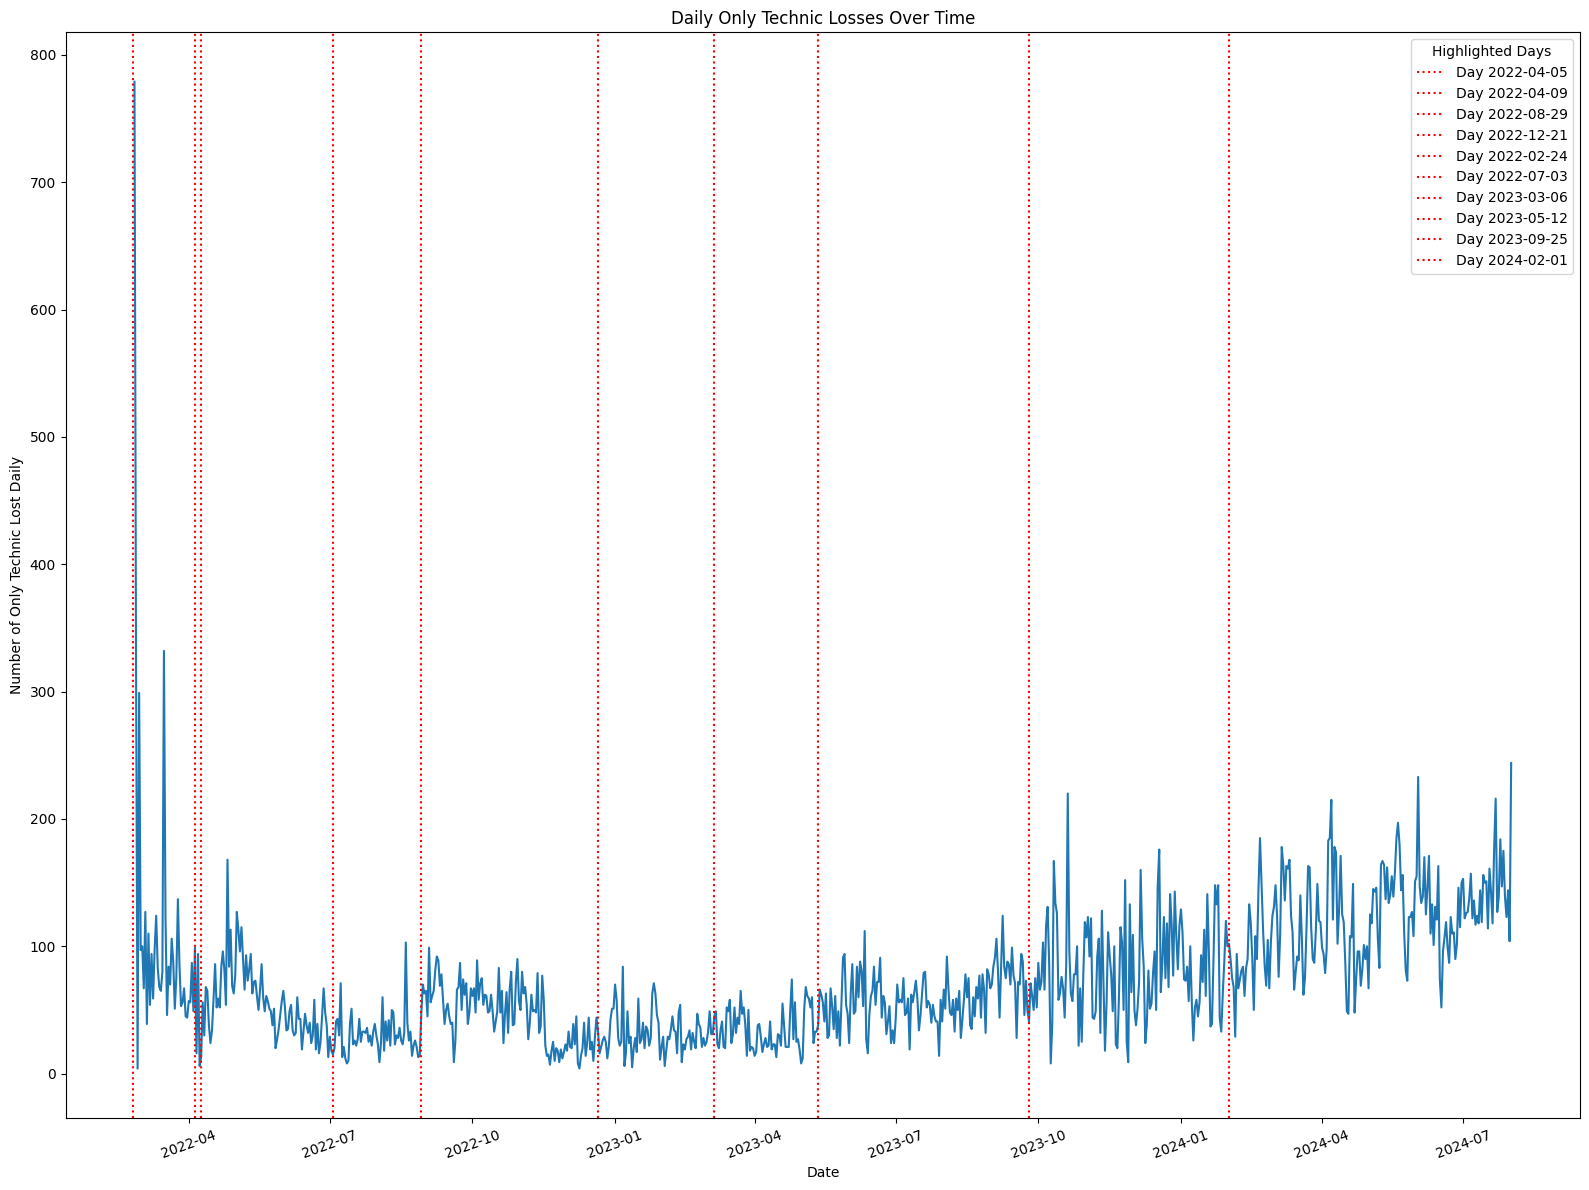

In [4]:
# Znazornim si denne straty techniky(aircraft, helicopter, tank, APC, drone, Vehicles and fuel tanks, submarines, naval ship, MRL, military auto, aircraft warfare, mobile SBRM system) 
# nasledne denne straty streliva a paliva (field artillery, cruise missiles, )

def sum_row_technic(row):
    return float(row['aircraft'] + row['helicopter'] + row['tank'] + row['APC'] + row['MRL']+ row['military auto'] + row['fuel tank'] + row['drone'] + row['naval ship']
                  + row['anti-aircraft warfare'] + row['mobile SRBM system'] + row['vehicles and fuel tanks'] + row['submarines'])

df['technic_total'] = df.apply(sum_row_technic, axis=1)

df['daily_only_technic_losses'] = (df['technic_total'].diff().shift(-1).fillna(0)).abs()  # Shift the losses up by one day
df.at[df.index[-1], 'daily_only_technic_losses'] = df.at[df.index[-1], 'technic_total']
print(df['daily_only_technic_losses'])

#Writing losses into files
with open('technic_total_file.txt','w') as f:
    for total in df['technic_total']:
        f.write(str(total)+'\n')
with open('daily_only_technic_losses.txt','w') as f:
    for total in df['daily_only_technic_losses']:
        f.write(str(total)+'\n')


dates_to_highlight = ['2022-04-05', '2022-04-09','2022-08-29','2022-12-21','2022-02-24','2022-07-03','2023-03-06','2023-05-12',
                      '2023-09-25','2024-02-01']

dates_to_highlight = [pd.to_datetime(date) for date in dates_to_highlight]

# Plot the daily technic losses
plt.figure(figsize=(16, 12))
plt.plot(df.index, df['daily_only_technic_losses'])

# Highlight specific dates with annotations
for date in dates_to_highlight:
    plt.axvline(x=pd.to_datetime(date), color='r', linestyle=':')  # Vertical dashed red line

lines, labels = [], []
for date in dates_to_highlight:
    label_date_str = date.strftime("%Y-%m-%d")
    lines.append(plt.Line2D([0], [0], color='r', linestyle=':'))
    labels.append(f'Day {label_date_str}')
plt.legend(lines, labels, loc='upper right', title="Highlighted Days")

plt.title('Daily Only Technic Losses Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Only Technic Lost Daily')
plt.xticks(rotation=20)  
plt.tight_layout()
plt.show()


date
2024-08-01    83382.0
2024-07-31    83089.0
2024-07-30    82953.0
2024-07-29    82757.0
2024-07-28    82540.0
               ...   
2022-03-01     1580.0
2022-02-28     1480.0
2022-02-27     1157.0
2022-02-26     1152.0
2022-02-25      828.0
Name: row_total, Length: 889, dtype: float64


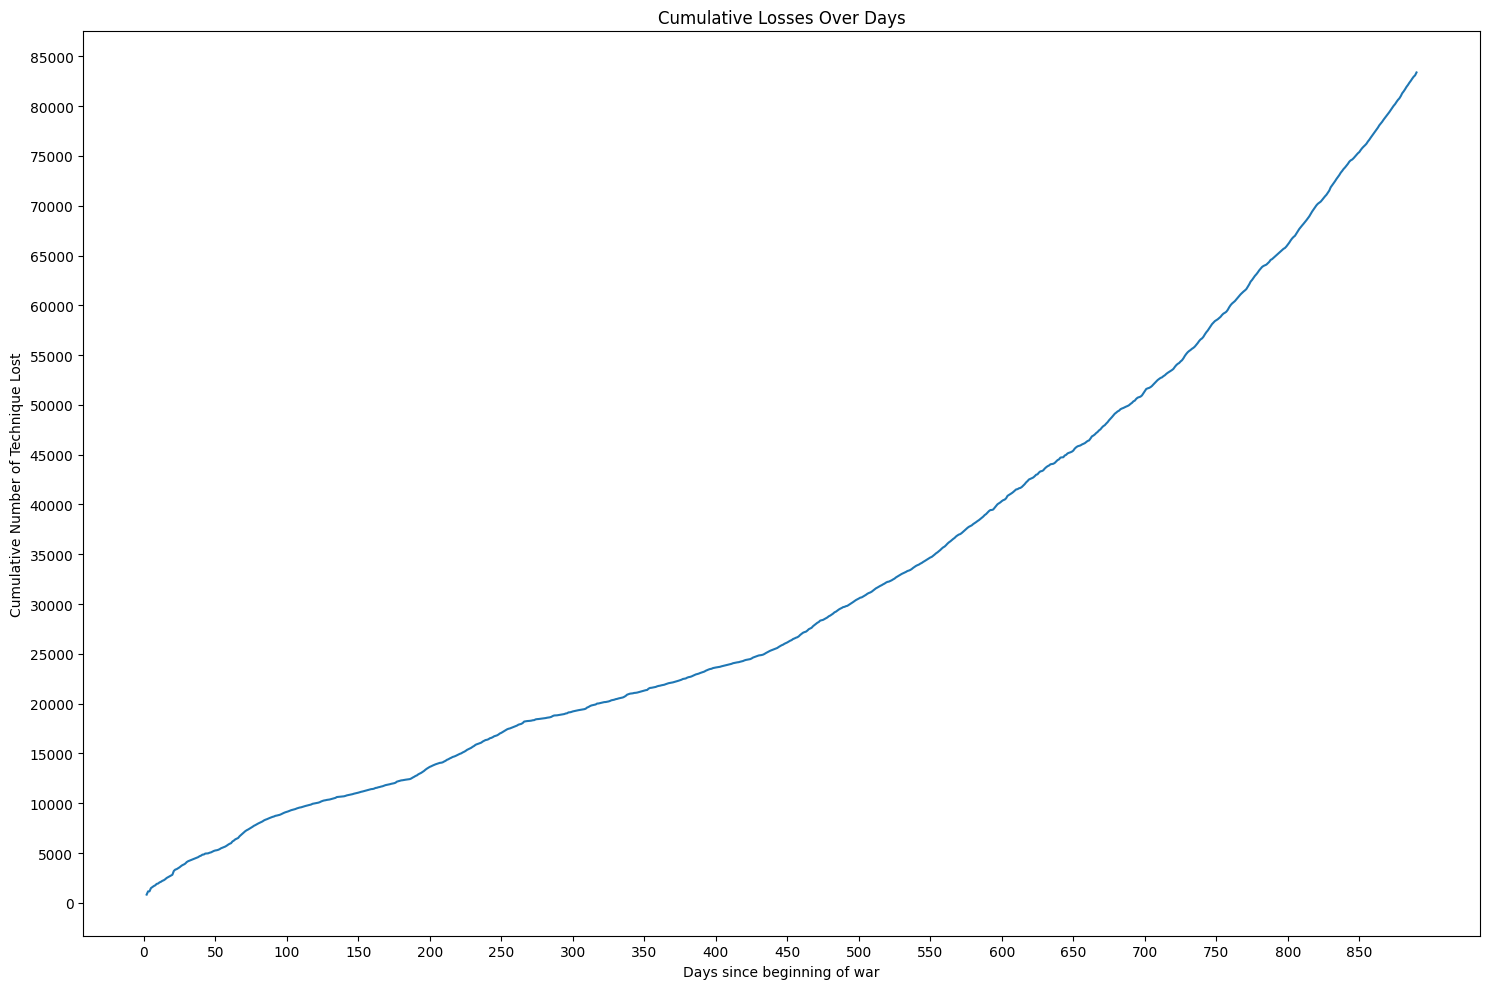

In [5]:
#Celkove kumulativne straty
def sum_row(row):
    return float(row['aircraft'] + row['helicopter'] + row['tank'] + row['APC'] + row['field artillery'] + row['MRL']+ row['military auto'] + row['fuel tank'] + row['drone'] + row['naval ship'] + row['anti-aircraft warfare'] + row['special equipment'] + row['mobile SRBM system'] + row['vehicles and fuel tanks'] + row['cruise missiles'] + row['submarines'])

# Apply the function to each row and store the result in a new column
df['row_total'] = df.apply(sum_row, axis=1)
print(df['row_total'])

#Writing losses into files
with open('cumulative_losses_all.txt','w') as f:
    for total in df['row_total']:
        f.write(str(total)+'\n')

# Plot the 'tank' column against the 'day' column
plt.figure(figsize=(15, 10))  # Optional: Adjusts the size of the plot
plt.plot(df['day'], df['row_total'])
plt.title('Cumulative Losses Over Days')  # Adds a title to the plot
plt.xlabel('Days since beginning of war')  # Adds a label to the x-axis
plt.ylabel('Cumulative Number of Technique Lost')  # Adds a label to the y-axis

# Set y-axis ticks to show every 100 units
plt.yticks(range(0, round(df['row_total'].max() + 500), 100))  # Adjust the second parameter to control the increment
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))  # Ensures y-axis ticks are at every 100 units

# Set x-axis ticks to show more precise increments, adjust as needed
plt.xticks(range(0, df['day'].max() + 10, 50))  # Adjust the second parameter to control the increment

plt.tight_layout()  # Adjusts subplot params so that the subplot(s) fits in to the figure area.
plt.show()


date
2024-08-01    33.0
2024-07-31    31.0
2024-07-30    46.0
2024-07-29    75.0
2024-07-28    53.0
              ... 
2022-03-01     3.0
2022-02-28    24.0
2022-02-27     1.0
2022-02-26     0.0
2022-02-25    49.0
Name: daily_munition_losses, Length: 889, dtype: float64


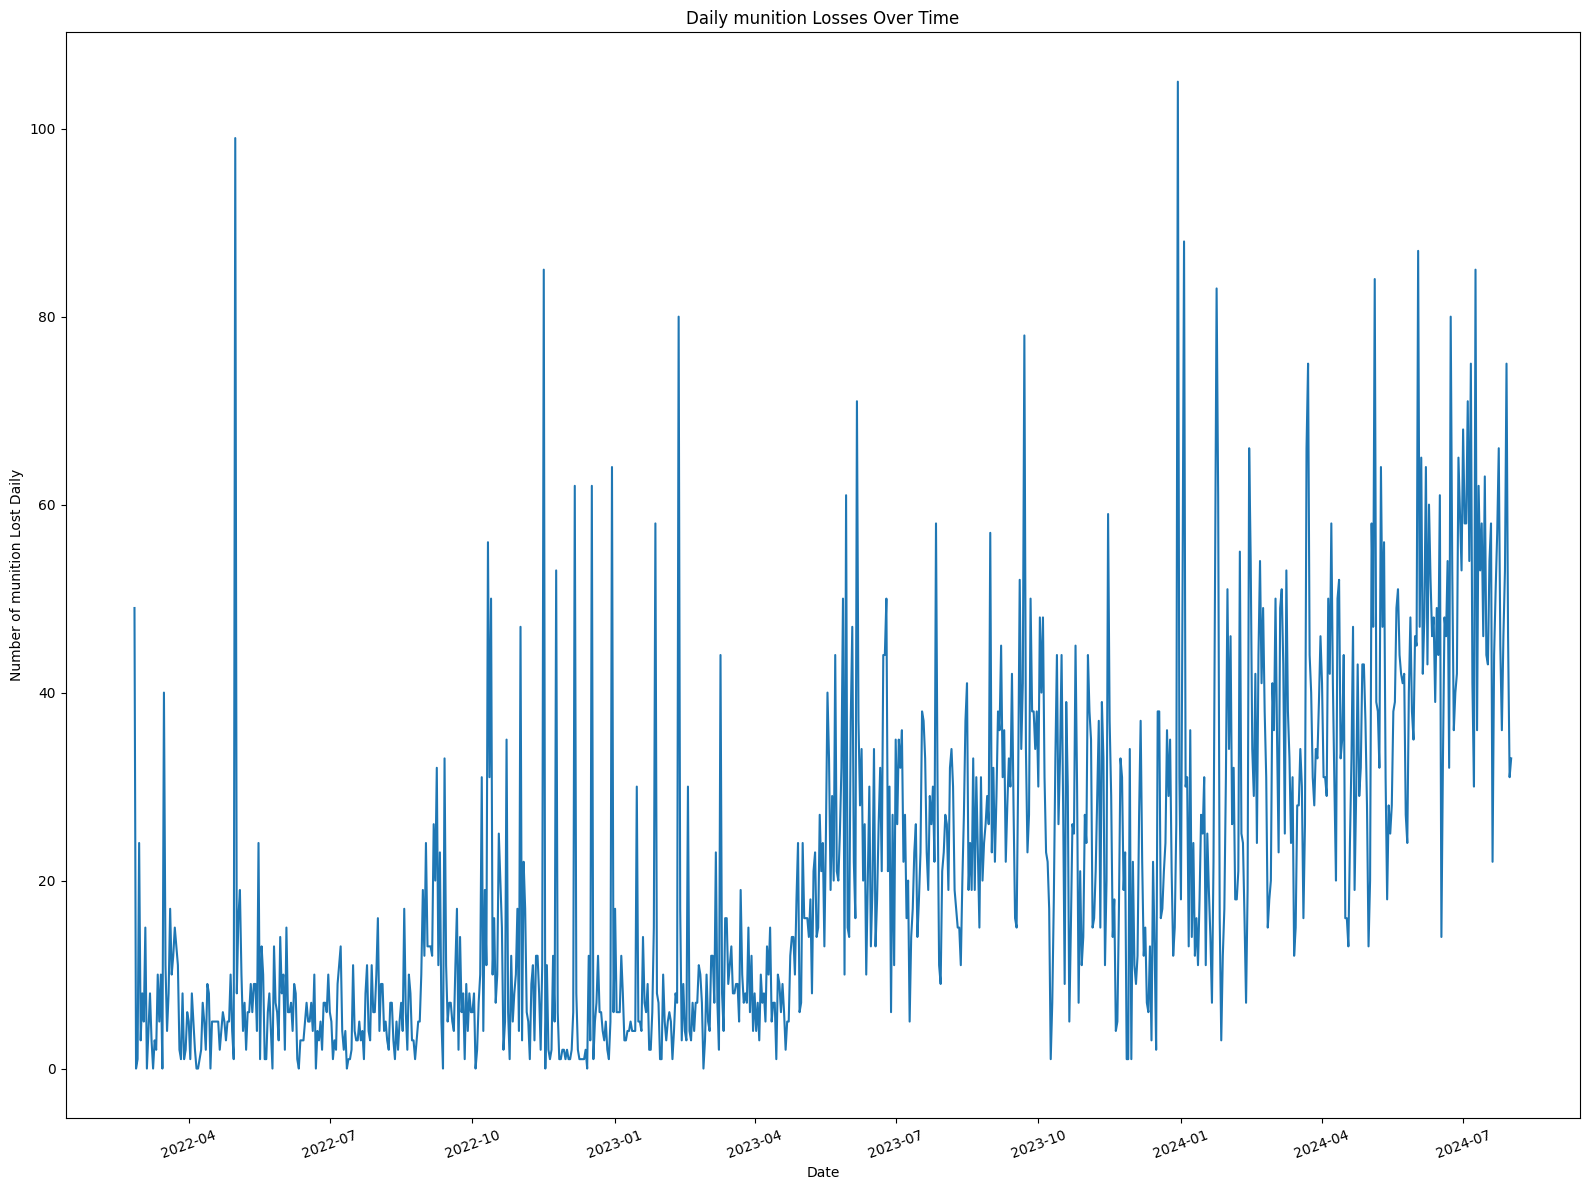

In [6]:
#cisto artileria/strelivo palivo
def sum_row_artillery(row):
       return float(row['field artillery'] + row['cruise missiles'] )

df['munition_total'] = df.apply(sum_row_artillery, axis=1)
df['daily_munition_losses'] = (df['munition_total'].diff().shift(-1).fillna(0)).abs()  
df.at[df.index[-1], 'daily_munition_losses'] = df.at[df.index[-1], 'munition_total']
print(df['daily_munition_losses'])

#Writing losses into files
with open('munition_total_losses.txt','w') as f:
    for total in df['munition_total']:
        f.write(str(total)+'\n')
with open('daily_munition_losses.txt','w') as f:
    for total in df['daily_munition_losses']:
        f.write(str(total)+'\n')

# Plot the daily artillery and fuel losses
plt.figure(figsize=(16, 12))
plt.plot(df.index, df['daily_munition_losses'])
plt.title('Daily munition Losses Over Time')
plt.xlabel('Date')
plt.ylabel('Number of munition Lost Daily')

plt.xticks(rotation=20) 
plt.tight_layout()
plt.show()


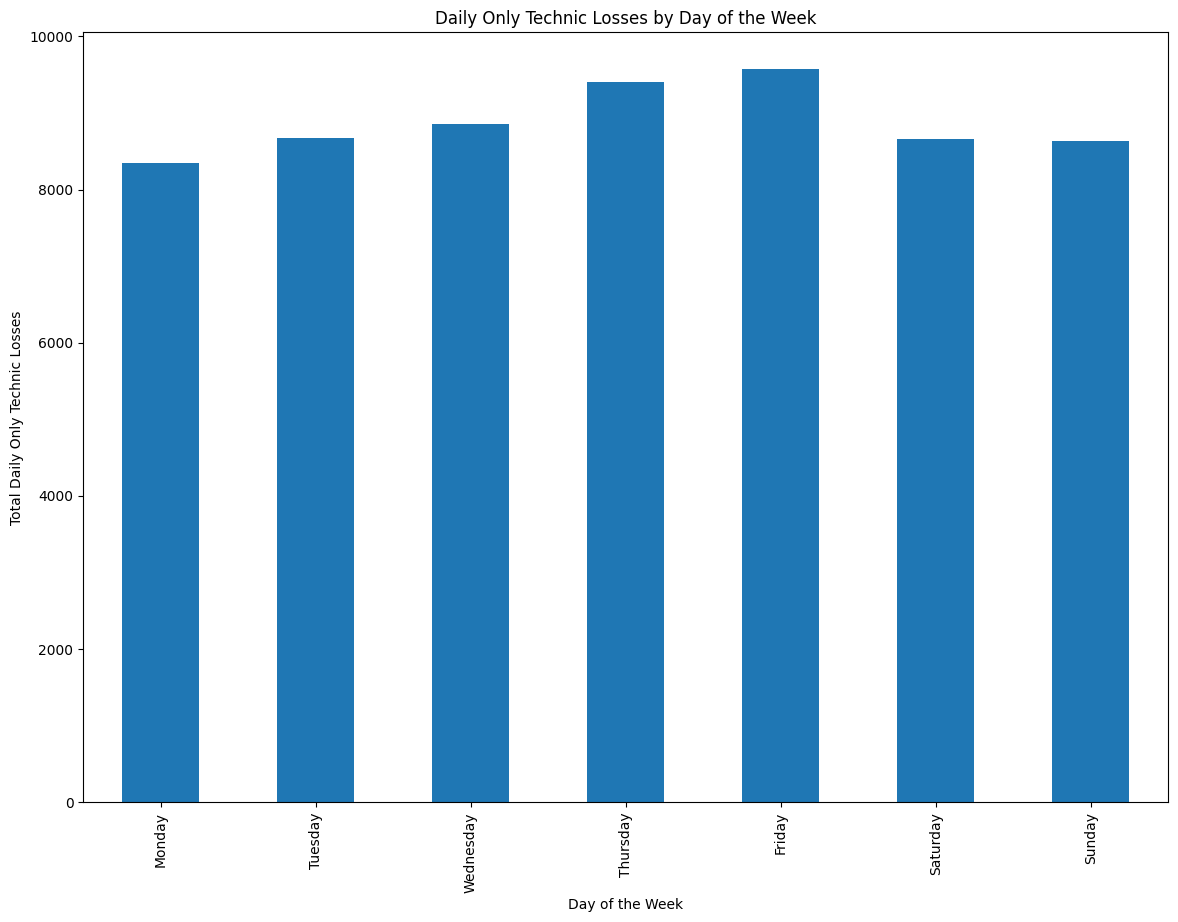

In [7]:
# Zobrazit stratu techniky podla dna v tyzdni

df['day_of_week'] = df.index.dayofweek  # Monday=0, Sunday=6
days_of_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day of the week and sum the daily_only_technic_losses
daily_only_technic_losses_by_day = df.groupby(df.index.dayofweek)['daily_only_technic_losses'].sum()

#Writing losses into files
with open('daily_only_technic_losses_total.txt','w') as f:
    for total in daily_only_technic_losses_by_day:
        f.write(str(total)+'\n')

# Plotting
plt.figure(figsize=(14, 10))
daily_only_technic_losses_by_day.plot(kind='bar')
plt.title('Daily Only Technic Losses by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Daily Only Technic Losses')
plt.xticks(ticks=range(7), labels=days_of_week)
plt.show()

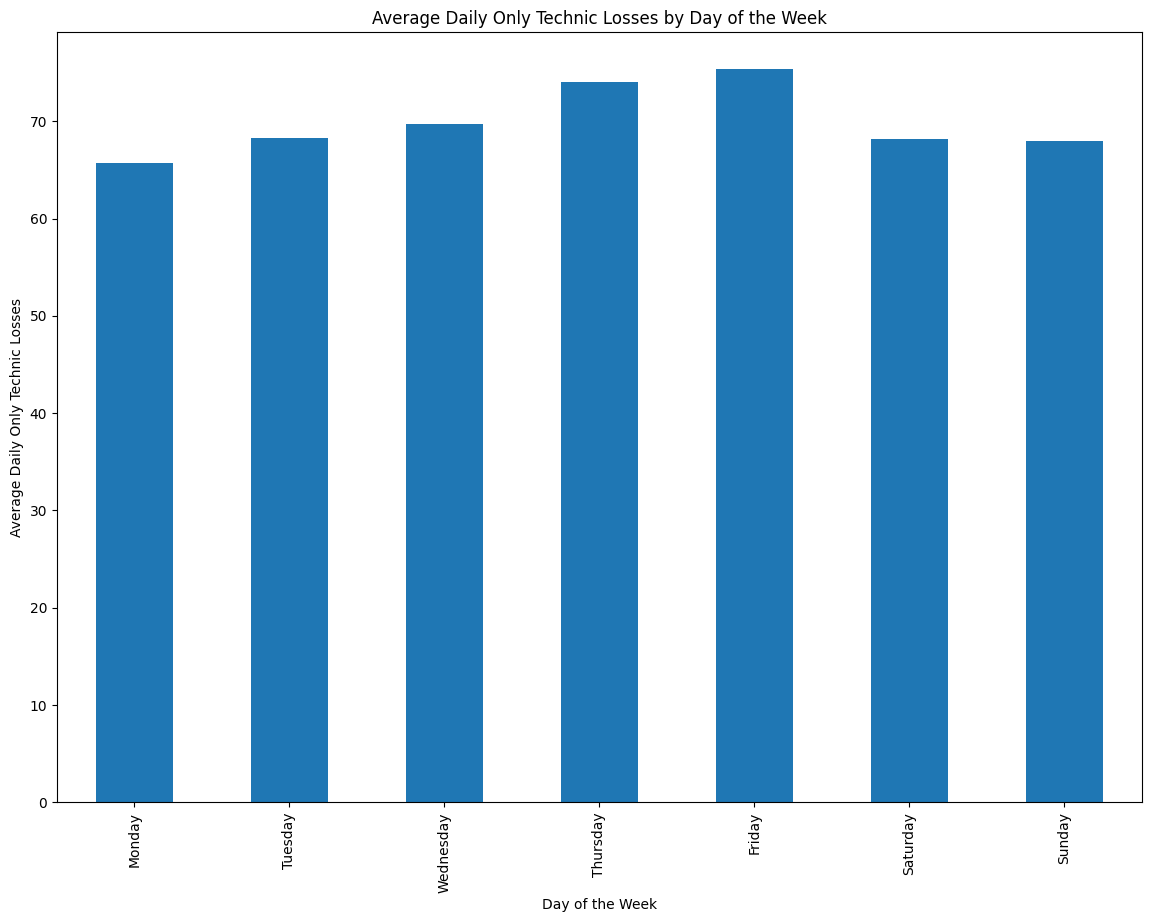

In [8]:
#priemerne straty zavisle od dní v tyzdni

# Group by day of the week, the average of daily_only_technic_losses for each day
average_losses_by_day = df.groupby(df.index.dayofweek)['daily_only_technic_losses'].mean()

#Writing losses into files
with open('average_losses_by_day.txt','w') as f:
    for total in average_losses_by_day:
        f.write(str(total)+'\n')

plt.figure(figsize=(14, 10))
average_losses_by_day.plot(kind='bar')
plt.title('Average Daily Only Technic Losses by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Daily Only Technic Losses')
plt.xticks(ticks=range(7), labels = days_of_week)
plt.show()

uistenie ze vsetkych dni mame rovnako
day_of_week
0    127
1    127
2    127
3    127
4    127
5    127
6    127
Name: count, dtype: int64


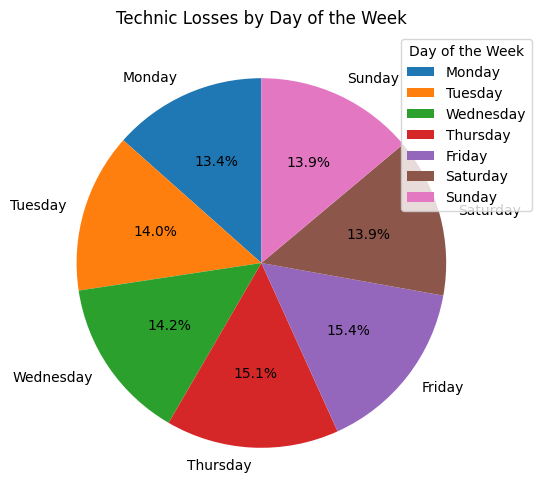

In [9]:
df['week_number'] = df.index.to_period('W').week
day_counts = df['day_of_week'].value_counts().sort_index()


print("uistenie ze vsetkych dni mame rovnako")
print(day_counts)

# Nacrt kolacovho grafu:
# Calculate total losses for each day of the week
total_losses_by_day = df.groupby('day_of_week')['daily_only_technic_losses'].sum()

plt.figure(figsize=(10, 6))
plt.pie(total_losses_by_day, labels=days_of_week, autopct='%1.1f%%', startangle=90)
plt.title('Technic Losses by Day of the Week')
plt.legend(title='Day of the Week', loc='upper right', bbox_to_anchor=(1.1, 1))
plt.show()

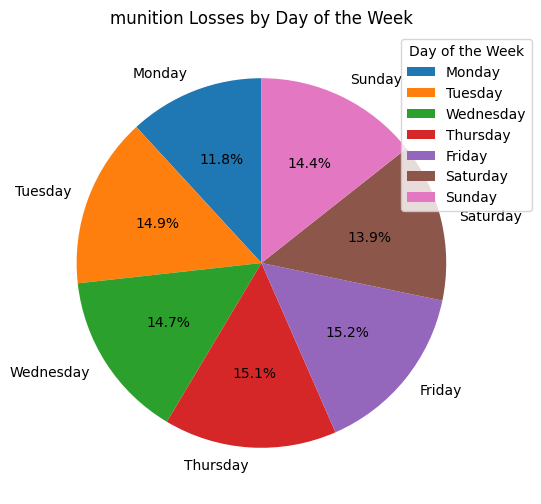

In [10]:
# Nacrt kolacovho grafu:
munition_losses_by_day = df.groupby('day_of_week')['daily_munition_losses'].sum()

plt.figure(figsize=(10, 6))
plt.pie(munition_losses_by_day, labels=days_of_week, autopct='%1.1f%%', startangle=90)
plt.title('munition Losses by Day of the Week')
plt.legend(title='Day of the Week', loc='upper right', bbox_to_anchor=(1.1, 1))
plt.show()

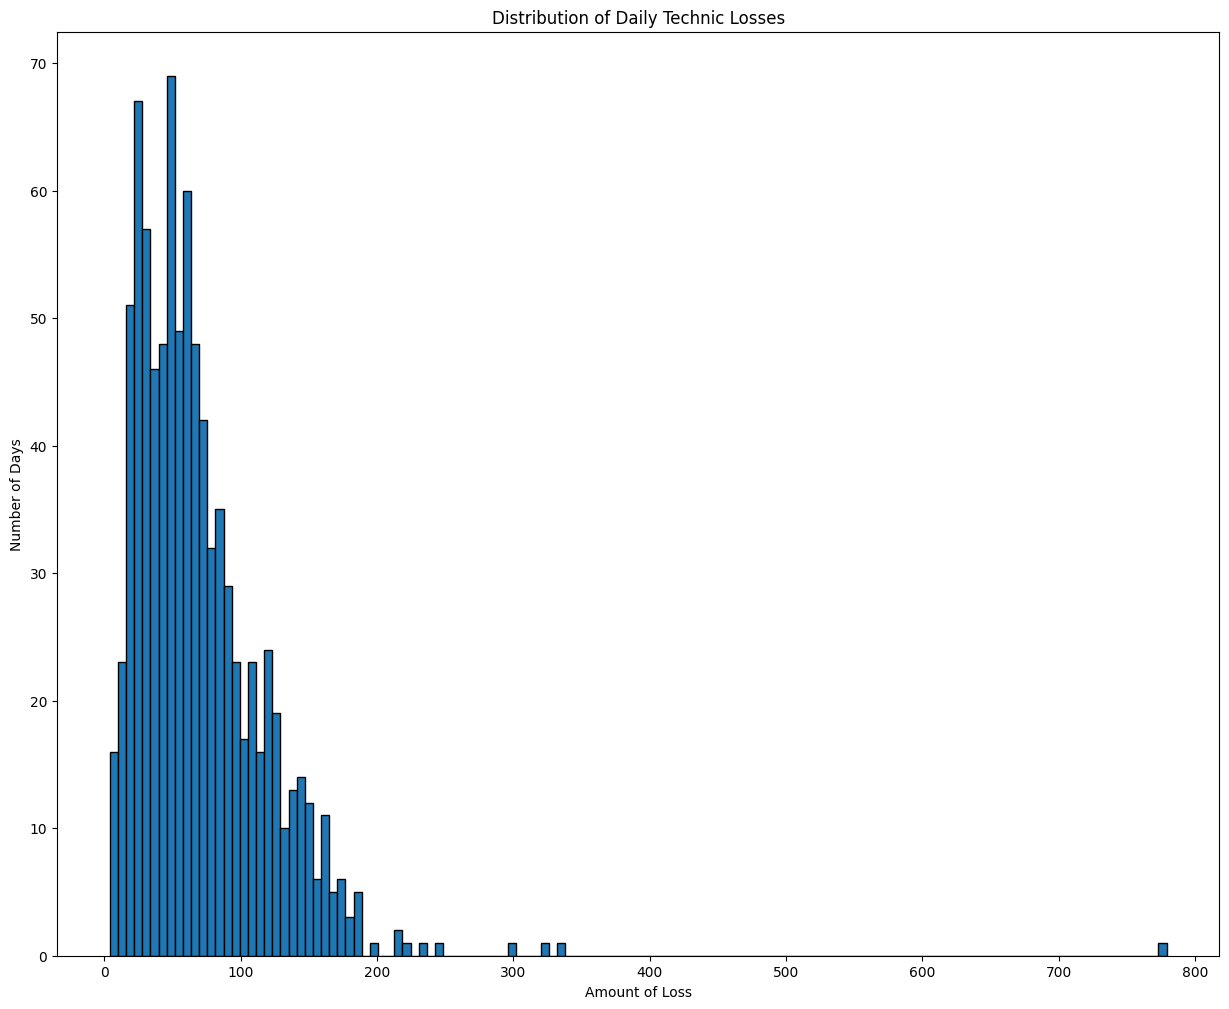

In [11]:
plt.figure(figsize=(15, 12))
plt.hist(df['daily_only_technic_losses'], bins=130, edgecolor='black')  
plt.title('Distribution of Daily Technic Losses')
plt.xlabel('Amount of Loss')
plt.ylabel('Number of Days')
plt.show()
# pripomina nejake deformovane normalne rozdelenie
# data su relativne normalne rozdelene

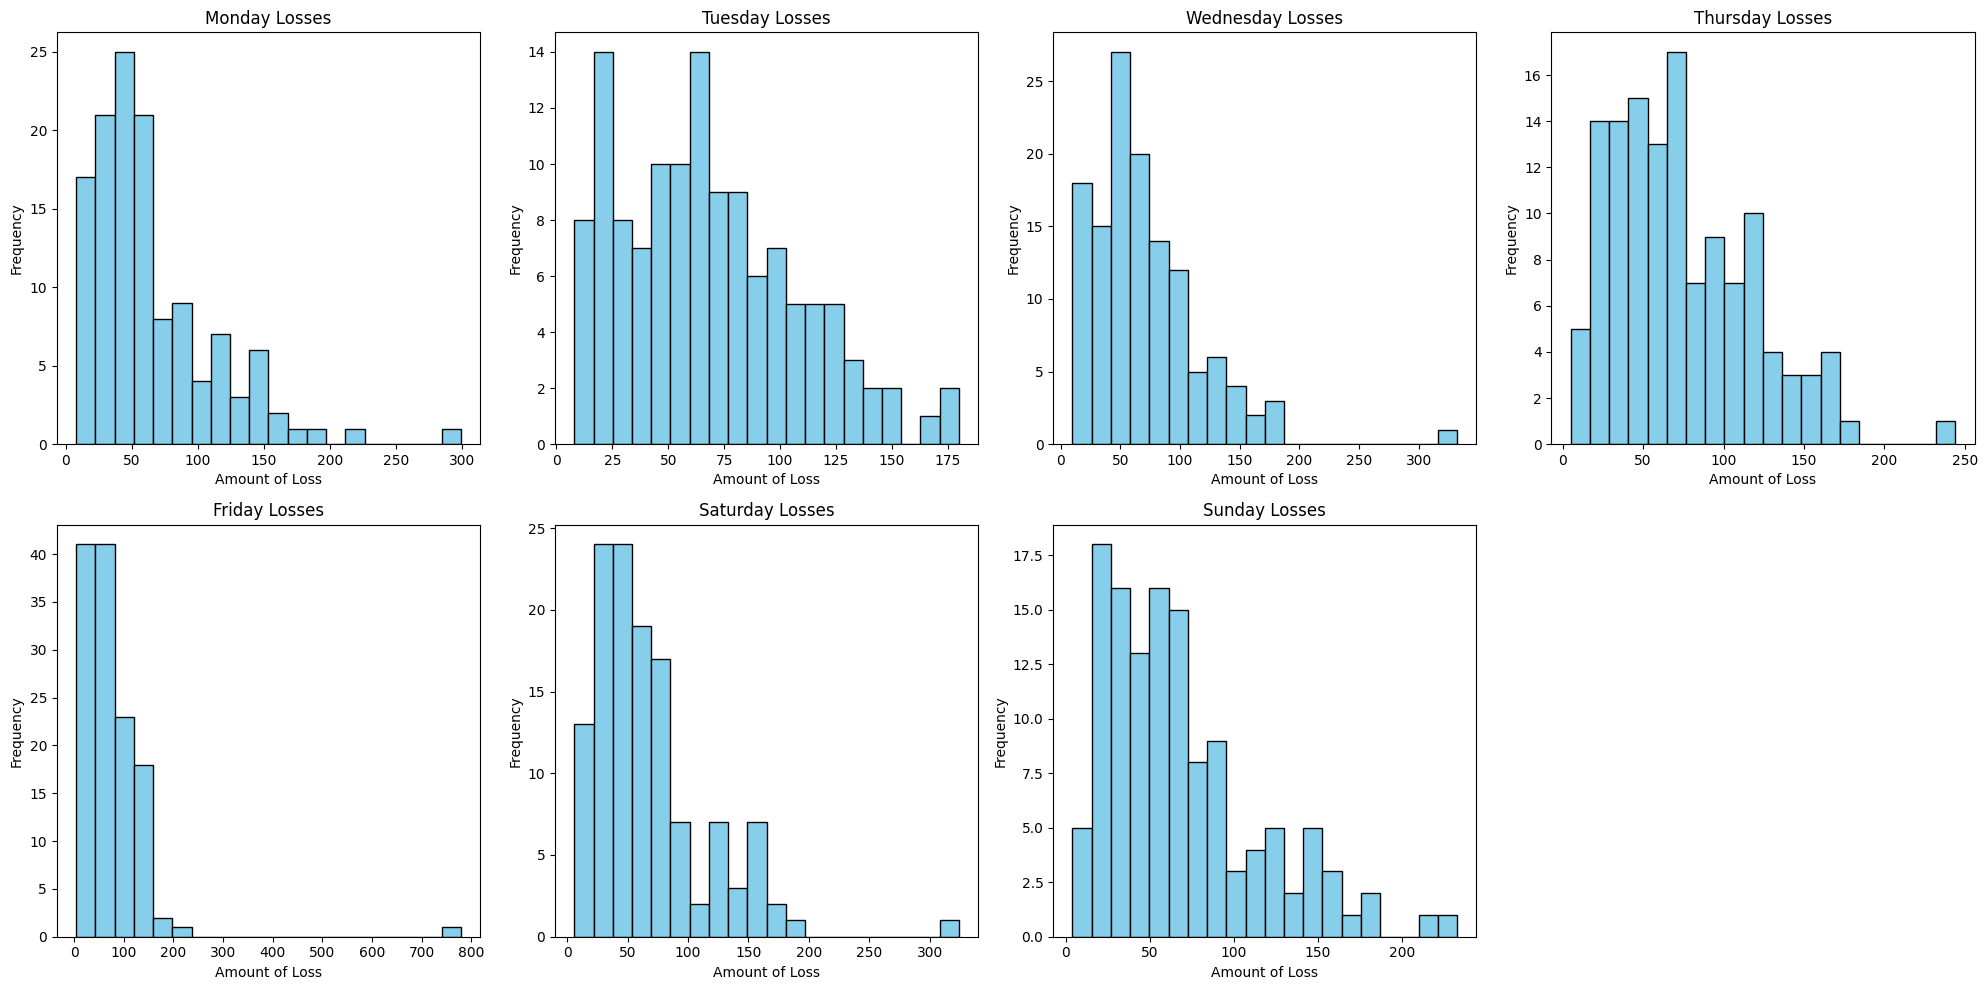

In [12]:
# Create a subplot for each day of the week with a 2x4 grid
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axs = axs.ravel()  # Flatten the array 

# limits for axis
x_min, x_max = 0, 1000  
y_min, y_max = 0, 500 

for i, day in enumerate(days_of_week):
    day_losses = df[df['day_of_week'] == i]['daily_only_technic_losses']
    # Plot histogram for the day
    axs[i].hist(day_losses, bins=20, edgecolor='black', color='skyblue')  # Adjust bins as needed
    axs[i].set_title(f'{day} Losses')
    axs[i].set_xlabel('Amount of Loss')
    axs[i].set_ylabel('Frequency')

# removing empty frame
if len(days_of_week) < len(axs):
    axs[-1].remove()  # This removes the last subplot if it's not used
plt.tight_layout()
plt.show()

In [13]:
# T-test
# spocita mi_r a urci t-hodnoty a p-hodnoty 
# one sample t-test
# two-tailed alternative='two-sided' is the default value, checking for a two-sided alternative hypothesis
average_daily_loss = df['daily_only_technic_losses'].mean()
print(average_daily_loss)

for day in days_of_week:
    day_losses = df[df['day_of_week'] == days_of_week.index(day)]['daily_only_technic_losses']
    # Perform one-sample t-test against the overall mean loss
    t_statistic, p_value = ttest_1samp(day_losses, average_daily_loss)
    print(f"{day}: T-statistic = {t_statistic}, P-value = {p_value}")

69.90213723284589
Monday: T-statistic = -0.9795458315490803, P-value = 0.3291874017438906
Tuesday: T-statistic = -0.46440215832118237, P-value = 0.6431610759445054
Wednesday: T-statistic = -0.04969671531621782, P-value = 0.9604427670342814
Thursday: T-statistic = 1.06016390717508, P-value = 0.2910980459223831
Friday: T-statistic = 0.8075698689149147, P-value = 0.4208601655627199
Saturday: T-statistic = -0.4087804514031083, P-value = 0.6833947309862864
Sunday: T-statistic = -0.45816042840044785, P-value = 0.647626376379667
